# Perbandingan Stabilitas Model pada Breast Cancer Wisconsin Diagnostic Dataset

Notebook ini digunakan untuk membandingkan Decision Tree, KNN, dan Random Forest berdasarkan hasil eksperimen 30 random seed.

Perbandingan difokuskan pada:
- Pola perubahan akurasi pada setiap seed
- Distribusi akurasi
- Rata-rata akurasi
- Tingkat kestabilan model

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

df_dt = pd.read_csv(
    "../../results/breast_cancer/breast_cancer_decision_tree.csv"
)

df_knn = pd.read_csv(
    "../../results/breast_cancer/breast_cancer_knn.csv"
)

df_rf = pd.read_csv(
    "../../results/breast_cancer/breast_cancer_random_forest.csv"
)

In [15]:
summary = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "KNN",
        "Random Forest"
    ],
    "Mean": [
        df_dt["accuracy_percent"].mean(),
        df_knn["accuracy_percent"].mean(),
        df_rf["accuracy_percent"].mean()
    ],
    "Minimum": [
        df_dt["accuracy_percent"].min(),
        df_knn["accuracy_percent"].min(),
        df_rf["accuracy_percent"].min()
    ],
    "Maximum": [
        df_dt["accuracy_percent"].max(),
        df_knn["accuracy_percent"].max(),
        df_rf["accuracy_percent"].max()
    ],
    "Median": [
        df_dt["accuracy_percent"].median(),
        df_knn["accuracy_percent"].median(),
        df_rf["accuracy_percent"].median()
    ],
    "Std Dev": [
        df_dt["accuracy_percent"].std(),
        df_knn["accuracy_percent"].std(),
        df_rf["accuracy_percent"].std()
    ]
})

summary["Range"] = (
    summary["Maximum"] - summary["Minimum"]
)

summary.round(2)

,Model,Mean,Minimum,Maximum,Median,Std Dev,Range
0,Decision Tree,92.92,86.84,97.37,93.86,3.17,10.53
1,KNN,97.16,92.98,99.12,97.37,1.41,6.14
2,Random Forest,96.32,93.86,99.12,96.49,1.39,5.26


## 1. Perubahan Akurasi terhadap Random Seed

Grafik berikut menunjukkan perubahan akurasi Decision Tree, KNN, dan Random Forest pada 30 variasi random seed.

Semakin besar perubahan naik-turun garis, semakin sensitif model terhadap perubahan pembagian data training dan testing.

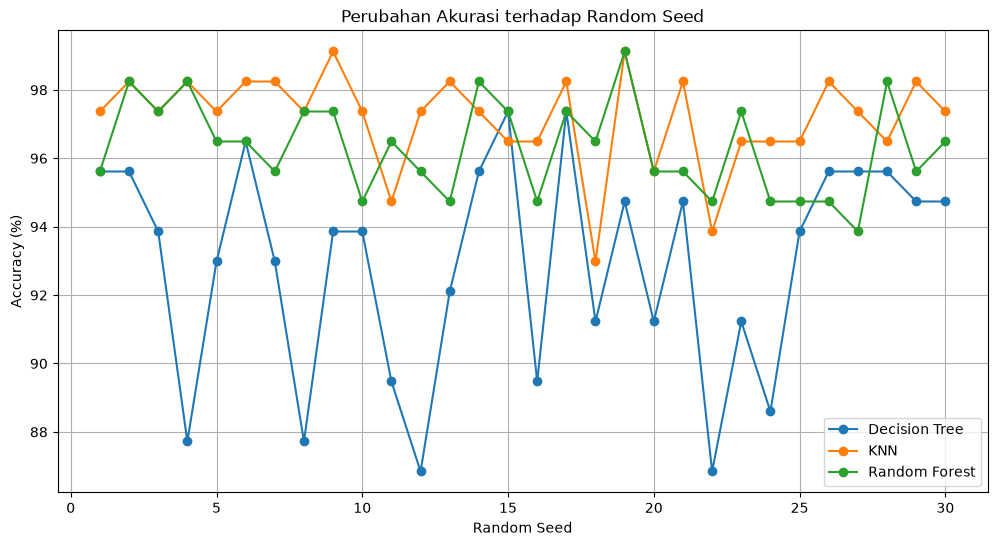

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    df_dt["seed"],
    df_dt["accuracy_percent"],
    marker="o",
    label="Decision Tree"
)

plt.plot(
    df_knn["seed"],
    df_knn["accuracy_percent"],
    marker="o",
    label="KNN"
)

plt.plot(
    df_rf["seed"],
    df_rf["accuracy_percent"],
    marker="o",
    label="Random Forest"
)

plt.xlabel("Random Seed")
plt.ylabel("Accuracy (%)")
plt.title("Perubahan Akurasi terhadap Random Seed")
plt.legend()
plt.grid(True)

plt.show()

## 2. Distribusi Akurasi

Boxplot digunakan untuk melihat penyebaran hasil akurasi setiap model.

Distribusi yang lebih sempit menunjukkan bahwa hasil model lebih konsisten, sedangkan distribusi yang lebih lebar menunjukkan sensitivitas yang lebih tinggi terhadap perubahan train-test split.

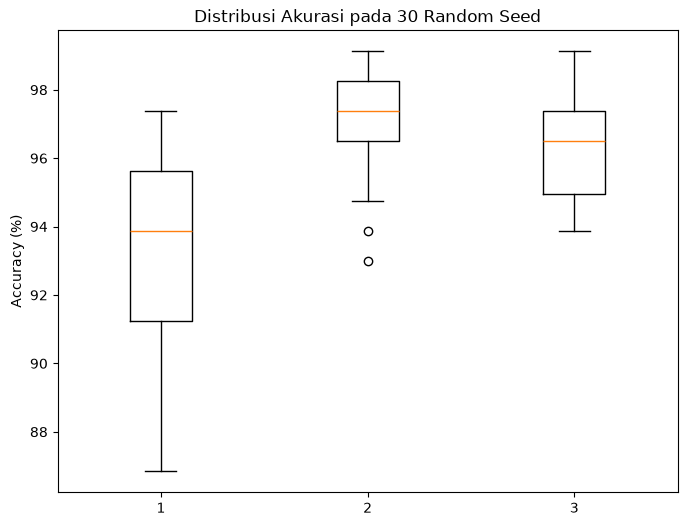

In [17]:
data_boxplot = [
    df_dt["accuracy_percent"],
    df_knn["accuracy_percent"],
    df_rf["accuracy_percent"]
]

plt.figure(figsize=(8, 6))

plt.boxplot(
    data_boxplot,
    label=[
        "Decision Tree",
        "KNN",
        "Random Forest"
    ]
)

plt.ylabel("Accuracy (%)")
plt.title("Distribusi Akurasi pada 30 Random Seed")

plt.show()

## 3. Perbandingan Rata-rata Akurasi

Grafik ini membandingkan rata-rata akurasi masing-masing algoritma selama 30 eksperimen.

Nilai yang lebih tinggi menunjukkan bahwa model secara umum memiliki tingkat prediksi yang lebih baik pada dataset ini.

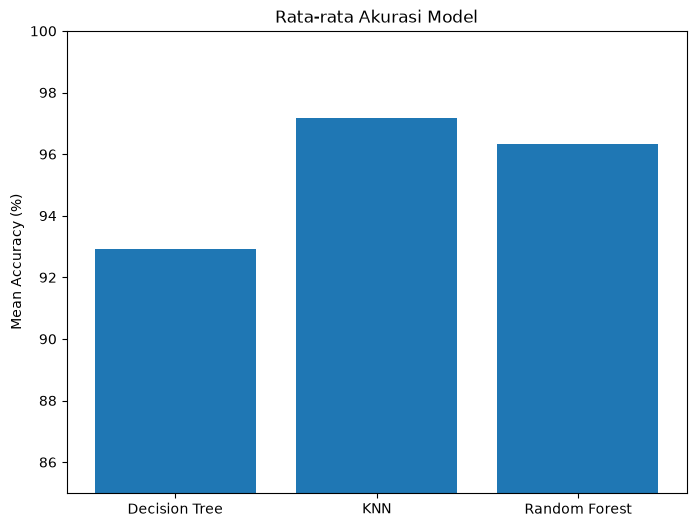

In [18]:
plt.figure(figsize=(8, 6))

plt.bar(
    summary["Model"],
    summary["Mean"]
)

plt.ylabel("Mean Accuracy (%)")
plt.title("Rata-rata Akurasi Model")

plt.ylim(85, 100)

plt.show()

## 4. Perbandingan Stabilitas Model

Standard deviation digunakan untuk mengukur tingkat penyebaran hasil akurasi.

Nilai standard deviation yang lebih kecil menunjukkan bahwa performa model lebih konsisten terhadap perubahan pembagian data training dan testing.

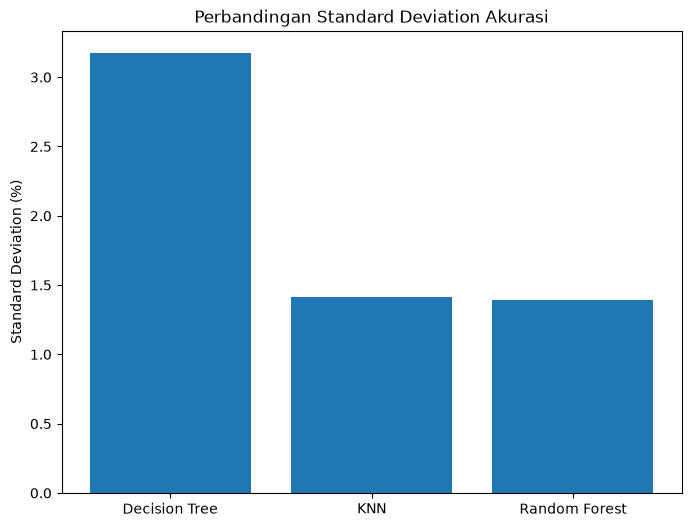

In [19]:
plt.figure(figsize=(8, 6))

plt.bar(
    summary["Model"],
    summary["Std Dev"]
)

plt.ylabel("Standard Deviation (%)")
plt.title("Perbandingan Standard Deviation Akurasi")

plt.show()

## 5. Rentang Perubahan Akurasi

Range menunjukkan selisih antara akurasi tertinggi dan akurasi terendah yang diperoleh selama 30 eksperimen.

Range yang lebih kecil menunjukkan bahwa performa model lebih tahan terhadap perubahan komposisi data training dan testing.

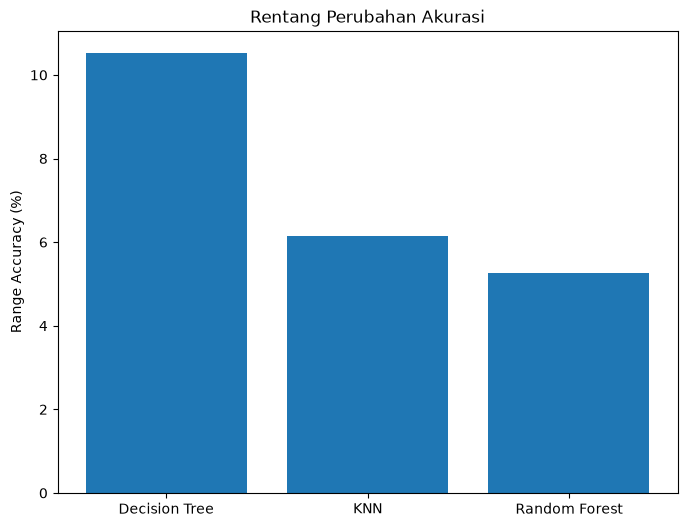

In [20]:
plt.figure(figsize=(8, 6))

plt.bar(
    summary["Model"],
    summary["Range"]
)

plt.ylabel("Range Accuracy (%)")
plt.title("Rentang Perubahan Akurasi")

plt.show()

In [21]:
summary.to_csv(
    "../../results/breast_cancer/breast_cancer_model_summary.csv",
    index=False
)

## 6. Analisis Perbandingan

Berdasarkan 30 variasi random seed, ketiga model menunjukkan tingkat performa dan kestabilan yang berbeda.

KNN menghasilkan rata-rata akurasi tertinggi sebesar sekitar 97.16%.

Random Forest memiliki rata-rata akurasi sedikit lebih rendah, yaitu sekitar 96.32%, tetapi menunjukkan tingkat kestabilan terbaik berdasarkan standard deviation dan range yang paling kecil.

Decision Tree memiliki rata-rata akurasi paling rendah dan variasi performa paling besar dibandingkan dua model lainnya.

Hasil ini menunjukkan bahwa model dengan rata-rata akurasi tertinggi belum tentu merupakan model yang paling stabil terhadap perubahan pembagian data.